In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sps
from PySpice.Spice.Netlist import *
from PySpice.Unit import *

In [2]:
def aproximacion_butterworth(Ap, Ar, fp, fr):
    """
    Calcula el orden N y la freuencia de corte fc del filtro pasabajas Butterworth,
    dadas las especificaciones relativas (Ap, fp), (Ar, fr)
    """
    N = int(np.ceil((np.log10((10**(Ap/10)-1)/(10**(Ar/10)-1)))/(2*np.log10(fp/fr))))
    fc = fp/(10**(Ap/10)-1)**(1/(2*N))
    return N, fc

In [3]:
def butterworth_pasabajas(N, fc):
    """
    Calcula los coeficientes b, a del filtro pasabajas Butterworth de orden N y frecuencia 
    de corte fc, así como su forma factorizada en la lista s. Cada entrada de s es una
    sección de primer o segundo orden: s = [[bi, ai],  ....]
    """
    # Calcula los polos
    p = np.array([np.exp(1j*(2*k-1)*np.pi/(2*N))*(np.exp(-1j*np.pi/2)) for k in range(1, 2*N+1)])
    p = np.array([2*np.pi*fc*pi for pi in p if pi.real <= 0])
    # Genera los coeficientes de H(s)
    a = np.poly(p).real
    b = np.array([(2*np.pi*fc)**N])
    # Ordena los polos para hacer las secciones
    inx = np.argsort(p.real)
    p = p[inx]
    # Inicializa la lista de secciones
    s = []
    # Sección de orden uno, si la hay
    if N%2 != 0:
        bi = np.array([-p[0].real])
        ai = np.array([1, -p[0].real])
        s.append([bi, ai])
        # Quita el polo real de la lista
        p = p[1:]
    # Secciones de orden dos
    for i in range(0, p.shape[0], 2):
        ai = np.poly(p[i:i+2]).real
        bi = np.array([ai[2]])
        s.append([bi, ai])
    return b, a, s

### Ejemplo de diseño

In [4]:
# (Paso 1) Especificación relativa
Ap, fp, Ar, fr = 0.1, 200, 60, 3000
# (Paso 2) Parámetros del filtro
N, fc = aproximacion_butterworth(Ap, Ar, fp, fr)
# (Paso 3) Coeficientes de las secciones
b, a, s = butterworth_pasabajas(N, fc)

In [5]:
print(N)

4


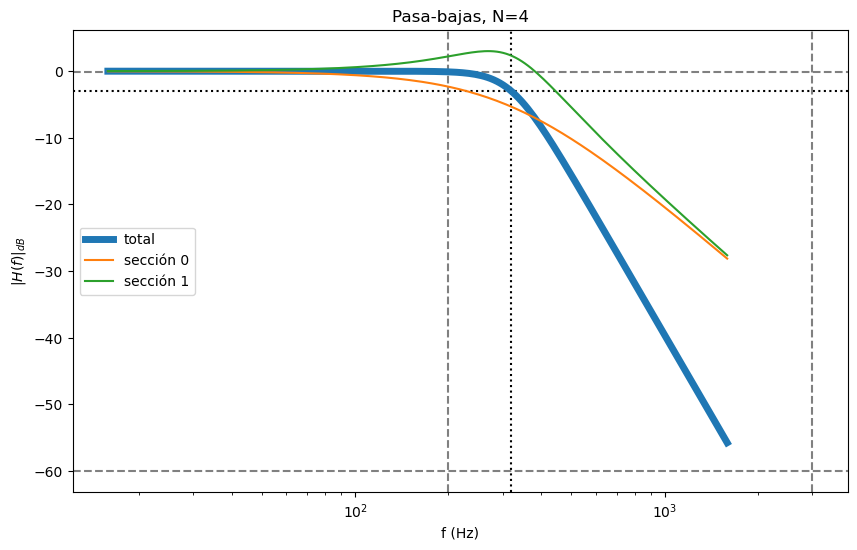

In [6]:
# Prepara gráfica con referencias relevantes
plt.figure(figsize=(10, 6))
plt.axhline(-Ap, color='gray', linestyle='--')
plt.axhline(-Ar, color='gray', linestyle='--')
plt.axhline(-3, color='black', linestyle=':')
plt.axvline(fp, color='gray', linestyle='--')
plt.axvline(fr, color='gray', linestyle='--')
plt.axvline(fc, color='black', linestyle=':')
# Respuesta en frecuencia total
W, H = sps.freqs(b, a)
f = W/(2*np.pi)
plt.semilogx(f, 20*np.log10(np.abs(H)), linewidth=5, label='total')
# Respuesta en frecuencia de cada sección
for i, [bi, ai] in enumerate(s):
    _, Hi = sps.freqs(bi, ai, W)
    plt.semilogx(f, 20*np.log10(np.abs(Hi)), label='sección {}'.format(i))
# Documenta la gráfica
plt.xlabel('f (Hz)')
plt.ylabel('$|H(f)|_{dB}$')
plt.title(f'Pasa-bajas, N={N}')
plt.legend();

## Topología Sallen-Key

<img src="https://drive.google.com/uc?export=download&id=11O4dDoqetPhtX4Fpx5-40IOOG3yHcY-r"></img>

## $H(s) = \frac{Y_1Y_2}{Y_1Y_2 +(Y_1+Y_2+Y_3)Y_4} = \frac{G_1G_2}{G_1G_2+(G_1+G_2+sC_3)sC_4}$

## $H(s) = \frac{G_1G_2}{C_3C_4s^2+(G_1+G_2)C_4s+G_1G_2} = \frac{\frac{G_1G_2}{C_3C_4}}{s^2+\frac{(G_1+G_2)}{C_3}s+\frac{G_1G_2}{C_3C_4}} = \frac{\frac{1}{R_1R_2C_3C_4}}{s^2+\frac{1}{(R_1||R_2)C_3}s+\frac{1}{R_1R_2C_3C_4}}$


### CUATRO incógnitas ... pero DOS ecuaciones

###  * proponer $C = C_3 = C_4/m$ reduce el problema a dos ecuaciones con dos incógnitas, más una condición a observar en $m$:

### $b_0 = a_0  = \frac{1}{R_1R_2C_3C_4}= \frac{1}{mR_1R_2C^2} \rightarrow R_1R_2 = \frac{1}{ma_0C^2}$

### $a_1 = \frac{R_1+R_2}{R_1R_2C_3} = \frac{R_1+R_2}{R_1R_2C} \rightarrow R_1R_2 = \frac{R_1+R_2}{a_1C} \rightarrow R_1+R_2 = \frac{a_1}{ma_0C}$

### $R_1\left(\frac{a_1}{ma_0C}-R_1\right) = \frac{1}{ma_0C^2} \rightarrow R_1 = \frac{a_1 \pm \sqrt{a_1^2-4ma_0}}{2ma_0C} \rightarrow m \le \frac{a_1^2}{4a_0}$

### Eligiendo la $m$ que anula el radical:

### $R_1 = \frac{a_1}{2ma_0C}$
### $R_2 = \frac{a_1}{ma_0C}-R_1 = \frac{a_1}{2ma_0C} \rightarrow R_1 = R_2$

###  * proponer $R = R_1 = R_2$ reduce el problema a dos ecuaciones con dos incógnitas también

### $b_0 = a_0  = \frac{1}{R_1R_2C_3C_4}= \frac{1}{R^2C_3C_4}$

### $a_1 = \frac{R_1+R_2}{R_1R_2C_3} = \frac{2}{RC_3} \rightarrow C_3 = \frac{2}{Ra_1} \rightarrow C_4=\frac{1}{R^2C_3a_0}=\frac{a_1}{2Ra_0}$

### que concuerda con el resultado anterior pues $m=\frac{C_4}{C_3}=\frac{a_1^2}{4a_0}$


In [7]:
def secciones_sallen_key(s, C=1e-6):
    """
    Calcula los componentes de cada sección, usando como base C3=1uF.
    Regresa la lista sk = [[R1, R2, C2], [R1i, R2i, C3i, C4i], ....] con los componentes
    de la sección de primer orden (si la hay) y los de las secciones de segundo orden
    """
    # Inicializa lista de componentes de sección
    sk = []
    # Para cada sección
    for i, [bi, ai] in enumerate(s):
        # Sección de primer orden
        if ai.shape[0] == 2:
            R = 1/(ai[1]*C)
            #print('sección {}: R1={:6.3f}k, R2={:6.3f}k, C2={:6.3f}u'.format(i, R/1e3, R/1e3, C/1e-6))
            sk.append([R/1e3, R/1e3, C/1e-6])
        # Sección de segundo orden
        else:
            m = (ai[1]**2)/(4*ai[2])
            R1 = ai[1]/(2*m*ai[2]*C)
            R2 = ai[1]/(m*ai[2]*C)-R1
            #print('sección {}: R1={:6.3f}k, R2={:6.3f}k, C3={:6.3f}u, C4={:6.3f}u'.format(i, R1/1e3, R2/1e3, C/1e-6, m*C/1e-6))
            sk.append([R1/1e3, R2/1e3, C/1e-6, m*C/1e-6])
    return sk

In [8]:
def sallen_key_pasabajas_spice(sk, spiceopus=False):
    """
    Genera una lista de red (netlist) para SPICE a partir de los componentes exactos
    """
    # Cadenas paramétricas de elementos del netlist
    MODELOS = '* Modelos\n.include tl081.mod\n'
    SENAL = '* Fuente de señal\nVin (vin 0) dc 0 ac 1.0v\n' 
    ALIMENTACION = '* Fuentes de alimentación\nVpp (vp 0) dc 15\nVnn (0 vn) dc 15\n'
    POrc = '*Seccion {0}\nR1{0} ({4} vi{0}) {1}k\nR2{0} (vi{0} {5}) {2}k\nC2{0} (vi{0} {5}) {3}u\n' 
    POopamp = 'X{0} (0 vi{0} vp vn {2}) TL081\n'
    SKrc = '*Seccion {0}\nR1{0} ({5} n0{0}) {1}k\nR2{0} (n0{0} vni{0}) {2}k\nC3{0} (n0{0} {6}) {3}u\nC4{0} (vni{0} 0) {4}u\n'
    SKopamp = 'X{0} (vni{0} {1} vp vn {1}) TL081\n'
    CTRL = '* Simulacion\n.control\ndestroy all\nac dec 10 0.1Hz 10MegHz\nplot db(mag(v(vout)/v(vin))) vs frequency\n+ xlabel "f (Hz)"\n+ ylabel "|H(f)|dB"\n.endc\n.end'
    
    # Inicializa el netlist con el encabezado básico
    netlist = MODELOS + SENAL + ALIMENTACION 
    # Agrega cada sección
    for i, ski in enumerate(sk):
        # Secciones de segundo orden Sallen-Key
        if len(ski) == 4:
            if i == 0:
                netlist = netlist + SKrc.format(i, ski[0], ski[1], ski[2], ski[3], 'vin', 'vout0')
                netlist = netlist + SKopamp.format(i, 'vout0')
            elif i == len(sk)-1:
                netlist = netlist + SKrc.format(i, ski[0], ski[1], ski[2], ski[3], 'vout{}'.format(i-1), 'vout')
                netlist = netlist + SKopamp.format(i, 'vout')
            else:
                netlist = netlist + SKrc.format(i, ski[0], ski[1], ski[2], ski[3], 'vout{}'.format(i-1), 'vout{}'.format(i))
                netlist = netlist + SKopamp.format(i, 'vout{}'.format(i))
        # Sección inversora de primer orden
        else:
            if i == 0:
                netlist = netlist + POrc.format(i, ski[0], ski[1], ski[2], 'vin', 'vout0')
                netlist = netlist + POopamp.format(i, 'vin', 'vout0')
            elif i == len(sk)-1:
                netlist = netlist + POrc.format(i, ski[0], ski[1], ski[2], 'vout{}'.format(i-1), 'vout')
                netlist = netlist + POopamp.format(i, 'vout{}'.format(i-1), 'vout')
            else:
                netlist = netlist + POrc.format(i, ski[0], ski[1], ski[2], 'vout{}'.format(i-1), 'vout{}'.format(i))
                netlist = netlist + POopamp.format(i, 'vout{}'.format(i-1), 'vout{}'.format(i)) 
    # Si se prefiere el netlist para SPICEopus
    if spiceopus:
        netlist = netlist + CTRL
    else:
        netlist = netlist + "\n.end\n"
    return netlist

### Ejemplo de diseño (cont)

In [14]:
# (Paso 4) Calcula componentes de las secciones
sk = secciones_sallen_key(s)
# (Paso 5) Simulación realista (SPICE) vs modelo (Python/Octave)
circuit = Circuit('PySPICE')
circuit.raw_spice = sallen_key_pasabajas_spice(sk, spiceopus=False)
# Despliega el netlist SPICE
print(circuit)

.title PySPICE
* Modelos
.include tl081.mod
* Fuente de señal
Vin (vin 0) dc 0 ac 1.0v
* Fuentes de alimentación
Vpp (vp 0) dc 15
Vnn (0 vn) dc 15
*Seccion 0
R10 (vin n00) 0.5383664038492557k
R20 (n00 vni0) 0.5383664038492557k
C30 (n00 vout0) 1.0u
C40 (vni0 0) 0.8535533905932735u
X0 (vni0 vout0 vp vn vout0) TL081
*Seccion 1
R11 (vout0 n01) 1.2997314736989025k
R21 (n01 vni1) 1.2997314736989025k
C31 (n01 vout) 1.0u
C41 (vni1 0) 0.14644660940672646u
X1 (vni1 vout vp vn vout) TL081

.end




In [15]:
sim = circuit.simulator()
analysis = sim.ac(start_frequency=1@u_Hz, stop_frequency=1@u_MHz, number_of_points=10,  variation='dec')

run simulation not started


NgSpiceCommandError: Command 'run' failed

<a href="http://caffeineowl.com/electronics/calcs/rescomb/index.html"> Calculadora de R comerciales</a>

In [ ]:
# Prepara gráfica con referencias relevantes
plt.figure(figsize=(10, 6))
plt.axhline(-Ap, color='gray', linestyle='--')
plt.axhline(-Ar, color='gray', linestyle='--')
plt.axhline(-3, color='black', linestyle=':')
plt.axvline(fp, color='gray', linestyle='--')
plt.axvline(fr, color='gray', linestyle='--')
plt.axvline(fc, color='black', linestyle=':')
# Respuesta en frecuencia total (modelo)
plt.semilogx(f, 20*np.log10(np.abs(H)), linewidth=5, label='total')
# Respuesta en frecuencia total (SPICE)
plt.semilogx(sim.frequency, 20*np.log10(np.abs(sim.nodes['vout']/sim.nodes['vin'])), label='SPICE', color='red')
# Documenta la gráfica
plt.xlabel('f (Hz)')
plt.ylabel('$|H(f)|_{dB}$')
plt.title(f'Pasa-bajas, N={N}')
plt.legend();